Проектная работа. Группа 10. Обучение с учителем: Логистическая регрессия. Хуснутдинов Эдуард Ринатович. Нуман Ахмед. Эспиноза Ортис Хуан Карлос

# Упражнения по логистической регрессии

**Задача:** Создать классификационную модель для прогнозирования того, сменит ли сотрудник работу, на основе следующих характеристик: 'city_development_index', 'experience', 'last_new_job', 'training_hours', 'no_job_info', 'is_university_enrolled'


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Данные

Целевая переменная указывает, меняет ли сотрудник работу: 0 означает отсутствие смены работы, 1 — смену работы.

Содержимое

Информация об атрибутах:

Числовые признаки:

city_development_index — индекс развития города
experience — опыт работы (в годах)
last_new_job — время с последней смены работы (в годах)
training_hours — количество часов обучения
target — целевая переменная (статус поиска работы)

Бинарные признаки:

no_job_info — отсутствие информации о текущей работе
is_university_enrolled — зачисление в университет
relevent_experience_No relevent experience — отсутствие релевантного опыта

Категориальные признаки (one-hot encoding):

city_city_* — город проживания
company_type_* — тип компании
company_size_* — размер компании
enrolled_university_* — статус зачисления в университет
education_level_* — уровень образования
major_discipline_* — основная дисциплина
gender_* — пол


----

**ЗАДАЧА: Запустите ячейку ниже, чтобы прочитать файл с данными.**

In [2]:
df = pd.read_csv('X_prepared_sample.csv')

In [3]:
df.head()

,city_development_index,experience,last_new_job,training_hours,target,no_job_info,is_university_enrolled,relevent_experience_No relevent experience,city_city_10,city_city_100,...,education_level_5,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,major_discipline_not_stated,gender_Male,gender_Other,gender_not_stated
0,0.920,21.0,1.0,36.0,1.0,1,0,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0.776,15.0,5.0,47.0,0.0,0,0,True,False,False,...,False,False,False,False,False,True,False,True,False,False
2,0.624,5.0,0.0,83.0,0.0,1,1,True,False,False,...,False,False,False,False,False,True,False,False,False,True
3,0.789,0.0,0.0,52.0,1.0,0,1,True,False,False,...,False,True,False,False,False,False,False,False,False,True
4,0.767,21.0,4.0,8.0,0.0,0,0,False,False,False,...,False,False,False,False,False,True,False,True,False,False


In [4]:
df['target'].unique()

array([1., 0.])

### Анализ данных и визуализация данных

Можете дополнительно исследовать данные.

**ЗАДАНИЕ: Посмотрите, есть ли в наборе данных отсутствующие значения, и создайте статистический отчёт о числовых колонках, как показано ниже.**

In [5]:
# Напишите Ваш код здесь
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Columns: 161 entries, city_development_index to gender_not_stated
dtypes: bool(154), float64(5), int64(2)
memory usage: 41.1 KB


In [6]:
# Напишите Ваш код здесь
df.describe().T

,count,mean,std,min,25%,50%,75%,max
city_development_index,200.0,0.82937,0.118938,0.55,0.76,0.8965,0.92,0.949
experience,200.0,10.54000,6.985153,0.00,5.00,9.5000,16.25,21.000
last_new_job,200.0,2.05000,1.694656,0.00,1.00,1.0000,3.00,5.000
training_hours,200.0,62.09750,51.753200,2.00,22.00,45.5000,90.00,185.500
target,200.0,0.23000,0.421889,0.00,0.00,0.0000,0.00,1.000
no_job_info,200.0,0.25000,0.434099,0.00,0.00,0.0000,0.25,1.000
is_university_enrolled,200.0,0.24500,0.431166,0.00,0.00,0.0000,0.00,1.000


### Задачи по визуализации данных

**ЗАДАНИЕ: Нарисуйте график bar plot, показывающий количество точек для каждого значения target.**

<Axes: xlabel='target', ylabel='count'>

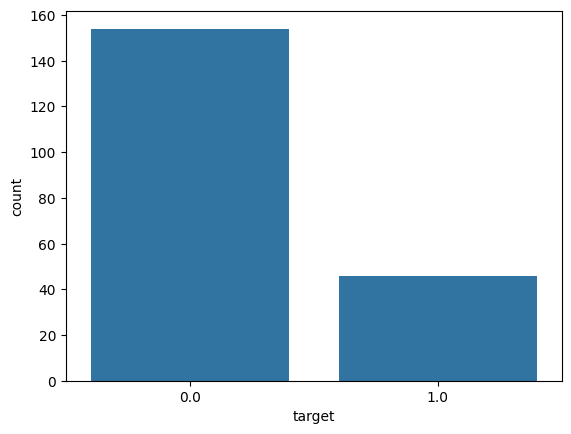

In [7]:
# Напишите Ваш код здесь
sns.barplot(df['target'].value_counts())

**ЗАДАНИЕ: Нарисуйте график pairplot, показывающий связи между следующими колонками:**

['city_development_index','experience', 'last_new_job','training_hours','no_job_info','is_university_enrolled','target']
   
*Замечание: если запустить pairplot по всем колонкам, то это заняло бы очень много времени, поскольку колонок много.*

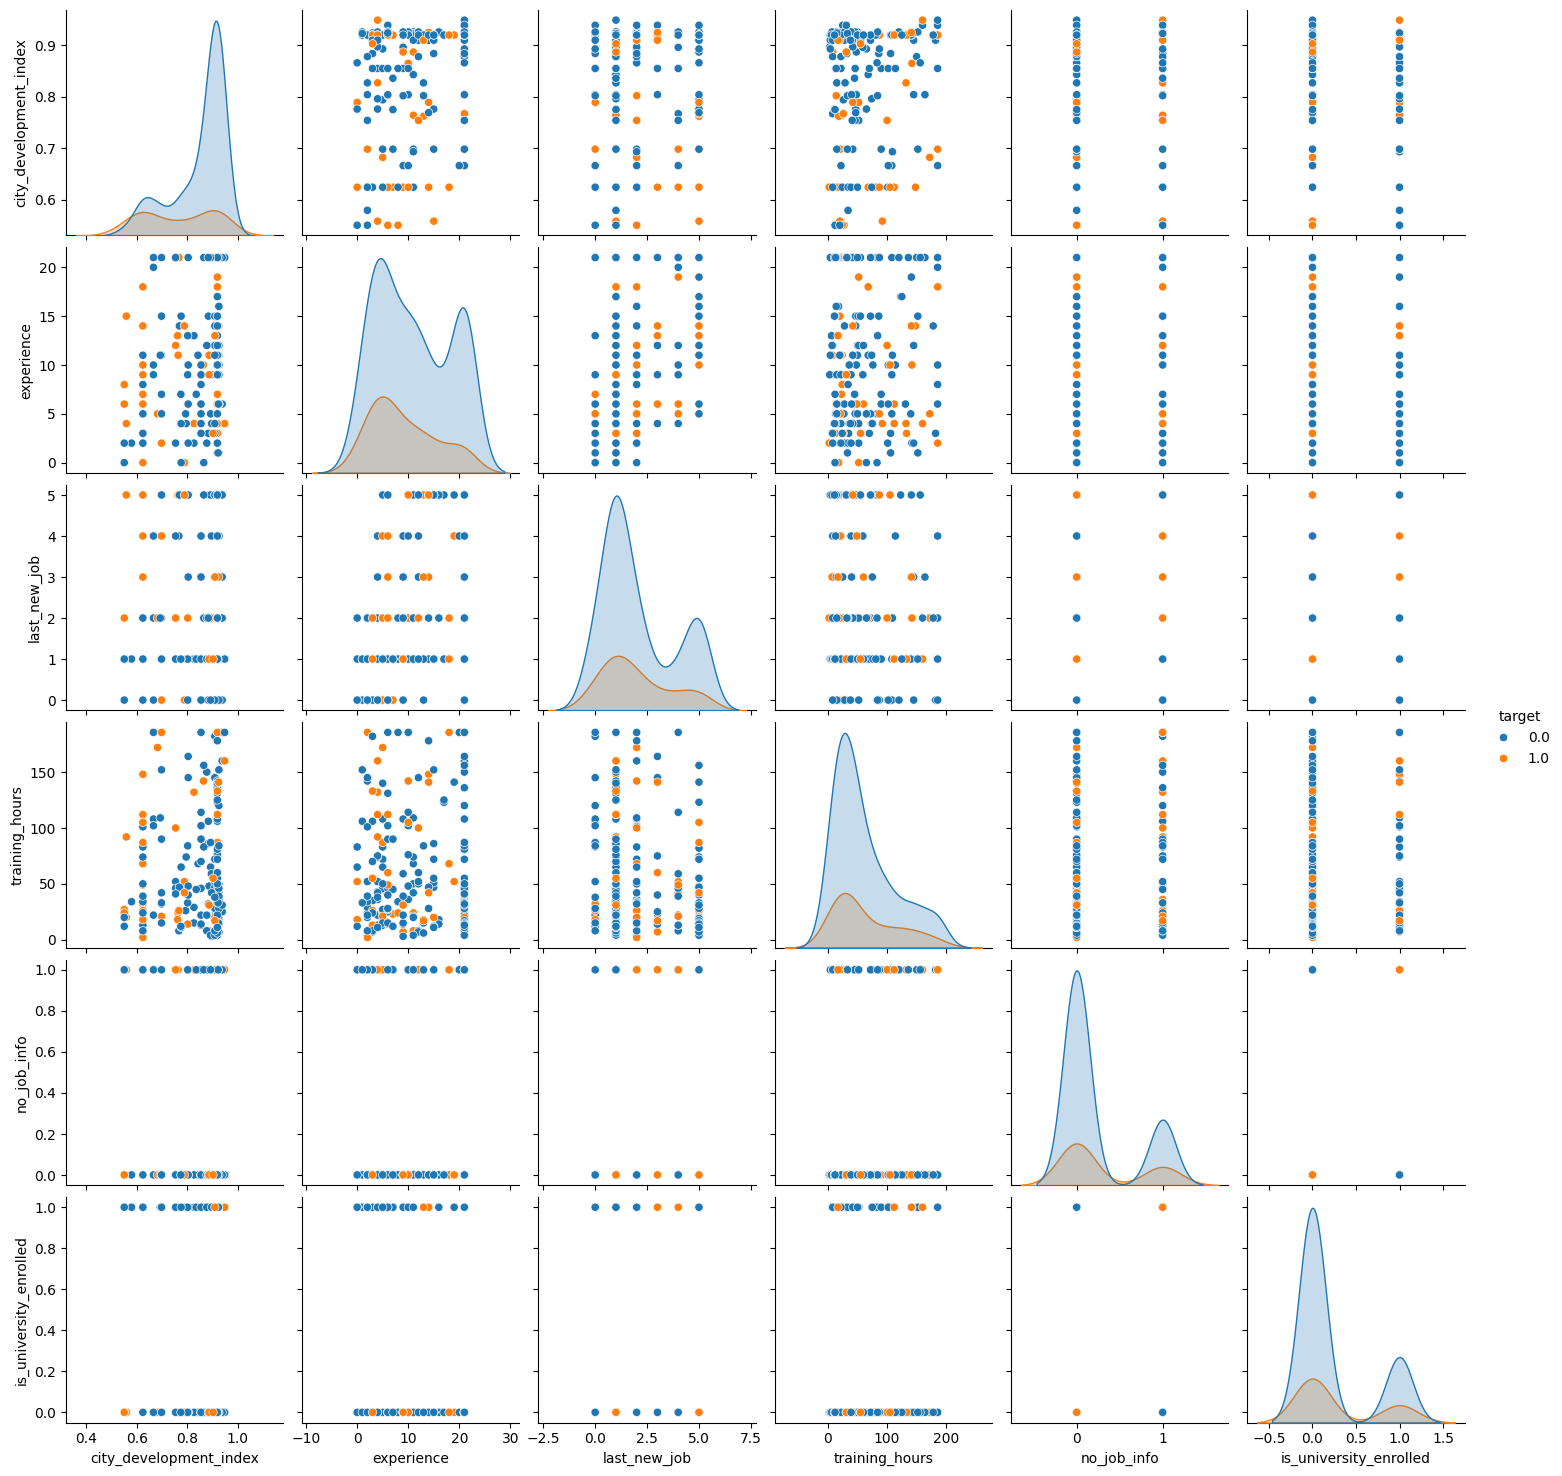

In [8]:
# Напишите Ваш код здесь
cols_plot = [
    'city_development_index',
    'experience',
    'last_new_job',
    'training_hours',
    'no_job_info',
    'is_university_enrolled',
    'target'
]
sns.pairplot(df[cols_plot],hue='target')

## Анализ pairplot

`city_development_index`
*  `target` 0 (синий) имеет более высокую концентрацию значений (~0,9)
*  `target` 1 (оранжевый) более рассредоточена и имеет более низкие значения

`experience`

Явно наблюдается различное распределение между классами:

*  `target` 1 → более сконцентрирована в группах с низким уровнем опыта
*  `target` 0 → более распределена

In [9]:
df.groupby('target')[['city_development_index','experience']].apply(pd.DataFrame.kurt)

,city_development_index,experience
target,,
0.0,0.461170,-1.384174
1.0,-1.646806,-0.777682


In [10]:
df.groupby('target')[['city_development_index','experience']].apply(pd.DataFrame.skew)


,city_development_index,experience
target,,
0.0,-1.327529,0.246581
1.0,-0.075478,0.614995


## Асимметрия (скошенность)


*  ≈ 0 → симметричное распределение
*  \> 0 → правостороннее (много малых значений, мало больших)
*  < 0 → левостороннее (много больших значений, мало малых)

## Эксцесс (куртозис)
*  ≈ 0 → похоже на нормальное распределение
*  \> 0 → больше пиков + больше выбросов (тяжелые хвосты)
*  < 0 → более плоское распределение (меньше экстремумов)

In [11]:
corr_cols = [
    'city_development_index',
    'experience',
    'last_new_job',
    'training_hours',
    'no_job_info',
    'is_university_enrolled',
    'target'
]
del_col = [col for col in df.columns if col not in corr_cols]
df = df.drop(columns=del_col)

In [12]:
df.columns

Index(['city_development_index', 'experience', 'last_new_job',
       'training_hours', 'target', 'no_job_info', 'is_university_enrolled'],
      dtype='str')

**ЗАДАНИЕ: Нарисуйте график heatmap, показывающий корреляции между всеми колонками.**

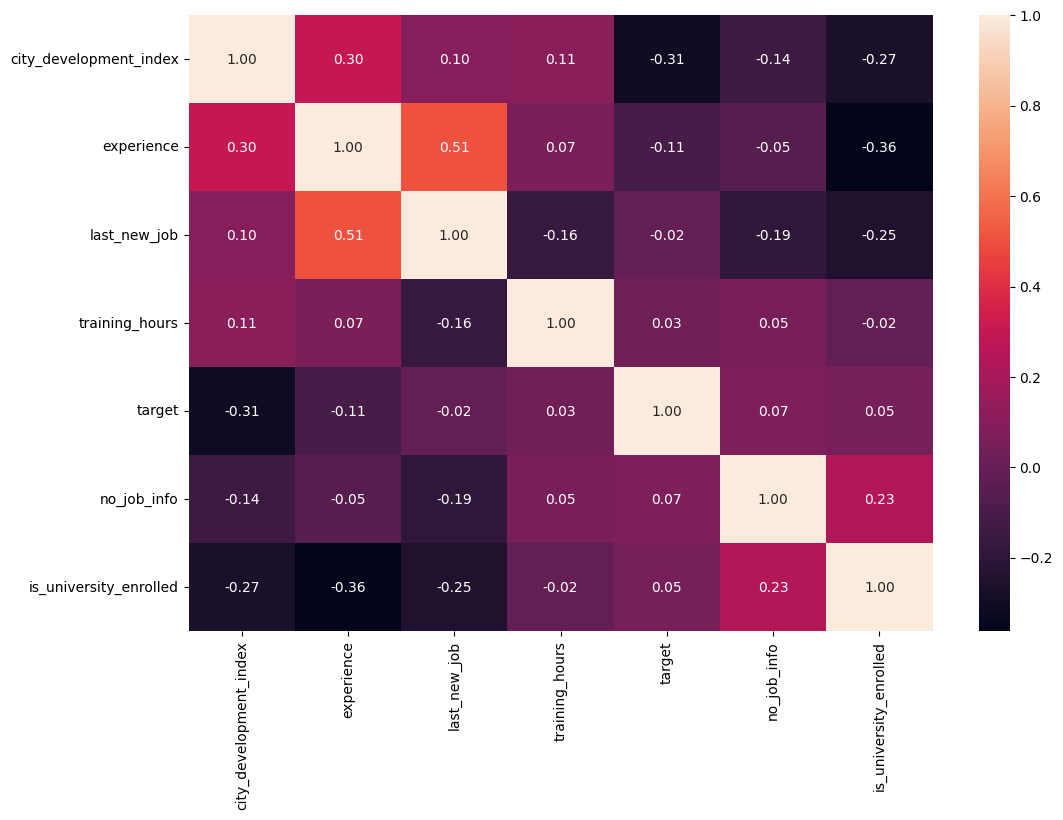

In [13]:
# Напишите Ваш код здесь
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(),annot=True, fmt='.2f')
plt.show()

## Анализ heatmap

`city_development_index`

* -0,31 → умеренная отрицательная корреляция

* Чем более `city_development_index` → тем ниже вероятность попадания в `target` = 1

`experience`

* -0,11 → слабая корреляция

* Больше `experience` → немного меньшая `target` = 1




----
----

# Машинное обучение

## Разбиение на обучающий и тестовый наборы данных, а также масштабирование данных

**ЗАДАНИЕ: разделите все признаки на 2 объекта, X и y.**

In [14]:
# Напишите Ваш код здесь
X, y = df.drop(columns='target'), df['target']

**ЗАДАНИЕ: разбейте данные на обучающий и тестовый наборы данных. Для тестовых данных используйте размер 10% и значение random_state=101.**

In [15]:
# Напишите Ваш код здесь
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

**ЗАДАНИЕ: С помощью объекта StandardScaler нормализуйте данные признаков в обучающем и тестовом наборах данных. При дальнейшем обучении модели убедитесь, что Вы проводите обучение только на обучающем наборе данных (без утечки данных из тестового набора данных).**

In [16]:
# Напишите Ваш код здесь
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## Модель логистической регрессии

**ЗАДАНИЕ: Создайте модель логистической регрессии, и с помощью кросс-валидации найдите хорошее значение значение C. У Вас здесь есть 2 варианта - либо *LogisticRegressionCV*, либо комбинация *LogisticRegression* и *GridSearchCV*. Выбор за Вами. В блокноте с решениями мы используем более простой способ с использованием *LogisticRegressionCV*.**

In [17]:
# Напишите Ваш код здесь
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 1000, 5000]
}

log_model = LogisticRegression(class_weight='balanced')

grid_model = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)


grid_model.fit(X_train,y_train)

/home/jc/Документы/UTMN/Магистратура/семестер 2/МО/Cross Validation/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/jc/Документы/UTMN/Магистратура/семестер 2/МО/Cross Validation/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/jc/Документы/UTMN/Магистратура/семестер 2/МО/Cross Validation/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ht='balanced')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'max_iter': [100, 1000, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['liblinear', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

**ЗАДАНИЕ: Отобразите результаты поиска оптимальных параметров, особенно значение C.**

*Замечание: Ваше значение может отличаться от найденного нами, поскольку оно зависит от метода поиска.*

In [18]:
grid_model.best_estimator_

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [19]:
# Напишите Ваш код здесь
grid_model.best_estimator_.C

0.1

In [20]:
grid_model.best_estimator_.get_params()

{'C': 0.1,
 'class_weight': 'balanced',
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 100,
 'n_jobs': None,
 'penalty': 'l1',
 'random_state': None,
 'solver': 'liblinear',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

### Коэффициенты

**ЗАДАНИЕ: Отобразите коэффициенты модели.**

In [21]:
grid_model.best_estimator_.coef_

array([[-0.46901751,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ]])

**БОНУСНОЕ ЗАДАНИЕ: Мы не показывали это в блокноте лекции, но у Вас есть все навыки, чтобы сделать это! Сделайте визуализацию коэффициентов, нарисуя их с помощью графика barplot. Дополнительно можете попробовать выяснить, как отсортировать график! Если что-то будет не получаться, то смело заглядывайте в блокнот с решениями - это можно сделать разными способами, в нашем решении мы используем комбинацию pandas и seaborn.**

<Axes: >

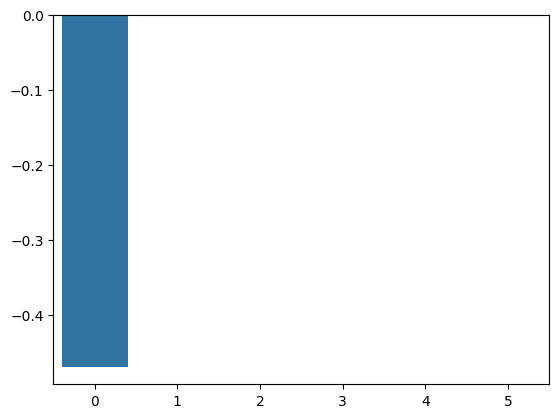

In [22]:
# Напишите Ваш код здесь


sns.barplot(grid_model.best_estimator_.coef_)

---------

## Оценка модели

**ЗАДАНИЕ: Оцените работу модели на оставшихся 10% данных - тестовом наборе данных.**

**ЗАДАНИЕ: Подготовьте следующие оценки:**
* Confusion Matrix Array
* Confusion Matrix Plot
* Classification Report

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

y_pred = grid_model.predict(X_test)

In [24]:
confusion_matrix(y_test,y_pred)

array([[16,  1],
       [ 3,  0]])

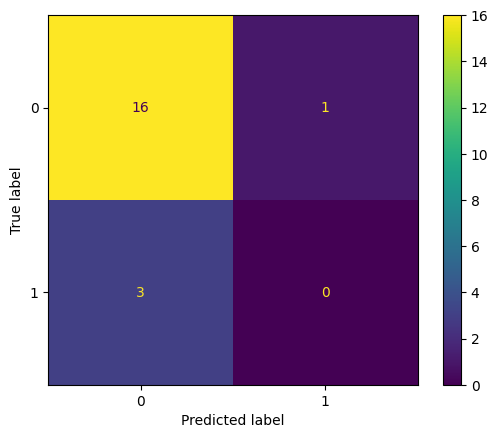

In [25]:
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred)).plot()

## Анализ матрицы ошибок

Модель хорошо предсказывает ситуации, когда смена работы не происходит (target = 0), и совершенно бесполезна для обнаружения смены работы (target = 1).

In [26]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.84      0.94      0.89        17
         1.0       0.00      0.00      0.00         3

    accuracy                           0.80        20
   macro avg       0.42      0.47      0.44        20
weighted avg       0.72      0.80      0.76        20



### Кривые производительности

**ЗАДАНИЕ: Нарисуйте графики "precision recall curve" и "ROC Curve".**

In [27]:
y_pred_prob = grid_model.predict_proba(X_test)[:, 1]

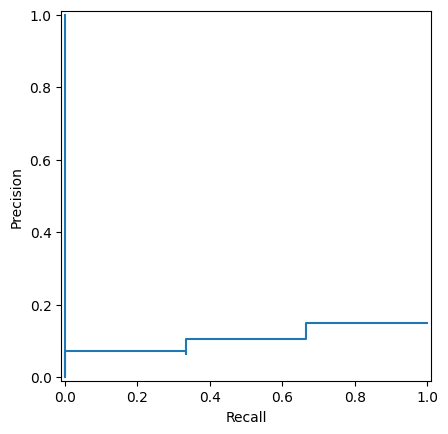

In [28]:
# Напишите Ваш код здесь
from sklearn.metrics import roc_curve, precision_recall_curve, auc, RocCurveDisplay, PrecisionRecallDisplay


precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
display = PrecisionRecallDisplay(precision=precision, recall=recall)
display.plot()

Модель хорошо справляется с обнаружением target= 0, но при попытке обнаружения target = 1 ее производительность резко падает.

ROC AUC: 0.13725490196078433


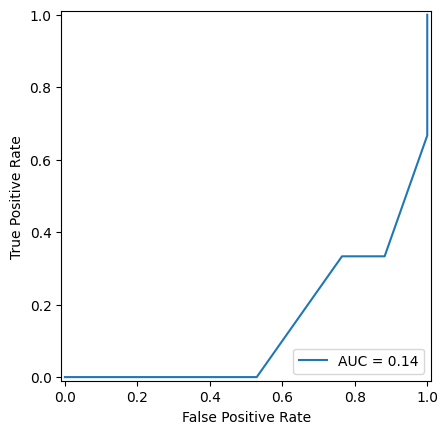

In [29]:
# Напишите Ваш код здесь
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)


roc_auc = auc(fpr, tpr)
roc_auc
print('ROC AUC:', roc_auc)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
display.plot()
plt.show()

Curve ROC показывает, что модель не делает предсказания для target = 0, демонстрируя увеличение числа ложных срабатываний по мере попытки предсказать target = 1.